# 🎓 Student Academic Performance — ML Modeling
**Project:** Data-Driven Framework for Student Performance Prediction  
**Input:** `student_features_engineered.csv`  
**Models:** Logistic Regression · Random Forest · XGBoost  
**Target:** `target_pass` (Binary: 1=Pass/Distinction, 0=Fail/Withdrawn)

---
### Pipeline
1. Load Engineered Dataset
2. Train / Test Split
3. Model 1 — Logistic Regression (Baseline)
4. Model 2 — Random Forest (Ensemble)
5. Model 3 — XGBoost (Gradient Boosting)
6. Model Comparison & Evaluation
7. Feature Importance Analysis
8. Confusion Matrices
9. ROC-AUC Curves
10. Save Models

## 1️⃣ Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import sys
!{sys.executable} -m pip install xgboost
import sys
!{sys.executable} -m pip install shap
# ── Sklearn ────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# ── XGBoost ────────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
SEED = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("✅ All libraries imported")

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

✅ All libraries imported


## 
2️⃣ Load Engineered Dataset

In [24]:
# ─── UPDATE PATH IF NEEDED ────────────────────────────────────────────────────
DATA_PATH = "student_features_engineered.csv"   # output from Feature Engineering notebook
# ──────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_PATH)
print(f"📦 Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
df.head(3)

📦 Loaded: 180,662 rows × 37 cols


,Unnamed: 0,education_level,age_numeric,imd_score,gender_binary,disability_flag,code_module_encoded,region_encoded,assessment_type_encoded,early_registration,...,module_avg_score,module_pass_rate,module_avg_clicks,relative_score_in_module,num_of_prev_attempts,studied_credits,module_presentation_length,id_student,target_pass,target_ordinal
0,0,0.75,2,1.0,1,0,0,0,2,1,...,0.0,1.0,0.419871,0.527755,0,240,268,11391,1,2
1,1,0.75,2,1.0,1,0,0,0,2,1,...,0.0,1.0,0.419871,0.947016,0,240,268,11391,1,2
2,2,0.75,2,1.0,1,0,0,0,2,1,...,0.0,1.0,0.419871,0.647544,0,240,268,11391,1,2


## 3️⃣ Prepare Features & Target

In [25]:
# Drop non-feature identifiers and alternative target
DROP_COLS = ['id_student', 'target_ordinal']
TARGET    = 'target_pass'

X = df.drop(columns=DROP_COLS + [TARGET], errors='ignore')
y = df[TARGET]

FEATURE_NAMES = list(X.columns)

print(f"🎯 Target  : {TARGET}  |  Classes: {sorted(y.unique())}")
print(f"📐 Features: {X.shape[1]}")
print(f"\n🔢 Class Distribution:")
vc = y.value_counts()
print(f"   Pass/Distinction (1) : {vc.get(1,0):>7,}  ({vc.get(1,0)/len(y)*100:.1f}%)")
print(f"   Fail/Withdrawn   (0) : {vc.get(0,0):>7,}  ({vc.get(0,0)/len(y)*100:.1f}%)")

🎯 Target  : target_pass  |  Classes: [np.int64(0), np.int64(1)]
📐 Features: 34

🔢 Class Distribution:
   Pass/Distinction (1) : 132,354  (73.3%)
   Fail/Withdrawn   (0) :  48,308  (26.7%)


## 4️⃣ Train / Validation / Test Split

In [26]:
# 70% Train | 15% Validation | 15% Test  — stratified to preserve class ratio
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=SEED, stratify=y_trainval
    # 0.1765 of trainval ≈ 15% of total
)

print(f"📊 Split Summary:")
print(f"   Train      : {X_train.shape[0]:>7,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation : {X_val.shape[0]:>7,} rows  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test       : {X_test.shape[0]:>7,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)")

📊 Split Summary:
   Train      : 126,458 rows  (70.0%)
   Validation :  27,104 rows  (15.0%)
   Test       :  27,100 rows  (15.0%)


---
## 🔵 Model 1 — Logistic Regression (Baseline)
> **Why:** Linear baseline; interpretable coefficients; fast training.  
> Scaled features required → wrapped in Pipeline.

In [27]:
# ── Build Pipeline ─────────────────────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                    max_iter=1000,
                    class_weight='balanced',   # handles class imbalance
                    C=1.0,                     # regularisation strength
                    solver='lbfgs',
                    random_state=SEED
               ))
])

# ── Train ──────────────────────────────────────────────────────────────────────
lr_pipeline.fit(X_train, y_train)

# ── Predict ────────────────────────────────────────────────────────────────────
lr_val_pred  = lr_pipeline.predict(X_val)
lr_test_pred = lr_pipeline.predict(X_test)
lr_test_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print("✅ Logistic Regression trained")
print("\n📋 Validation Classification Report:")
print(classification_report(y_val, lr_val_pred, target_names=['At-Risk','Pass']))

✅ Logistic Regression trained

📋 Validation Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.68      0.81      0.74      7248
        Pass       0.93      0.86      0.89     19856

    accuracy                           0.85     27104
   macro avg       0.80      0.84      0.82     27104
weighted avg       0.86      0.85      0.85     27104



In [28]:
# ── Cross-Validation ───────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lr_cv_scores = cross_val_score(lr_pipeline, X_trainval, y_trainval, cv=cv, scoring='roc_auc')

print(f"🔁 5-Fold CV ROC-AUC: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

# ── Test Metrics ───────────────────────────────────────────────────────────────
lr_metrics = {
    'Model'    : 'Logistic Regression',
    'Accuracy' : accuracy_score(y_test, lr_test_pred),
    'Precision': precision_score(y_test, lr_test_pred),
    'Recall'   : recall_score(y_test, lr_test_pred),
    'F1'       : f1_score(y_test, lr_test_pred),
    'ROC-AUC'  : roc_auc_score(y_test, lr_test_prob),
    'CV ROC-AUC Mean': lr_cv_scores.mean()
}
print("\n📊 Test Metrics:")
for k,v in lr_metrics.items():
    if k != 'Model': print(f"   {k:<20}: {v:.4f}")

🔁 5-Fold CV ROC-AUC: 0.9112 ± 0.0023

📊 Test Metrics:
   Accuracy            : 0.8476
   Precision           : 0.9245
   Recall              : 0.8624
   F1                  : 0.8924
   ROC-AUC             : 0.9100
   CV ROC-AUC Mean     : 0.9112


---
## 🟢 Model 2 — Random Forest (Ensemble)
> **Why:** Handles non-linearity and interactions; built-in feature importance; robust to outliers.

In [29]:
# ── Build Model ────────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,          # number of trees
    max_depth=15,              # prevent overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',       # feature subsampling per split
    class_weight='balanced',   # handles class imbalance
    n_jobs=-1,                 # use all CPU cores
    random_state=SEED
)

# ── Train ──────────────────────────────────────────────────────────────────────
rf_model.fit(X_train, y_train)

# ── Predict ────────────────────────────────────────────────────────────────────
rf_val_pred  = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)
rf_test_prob = rf_model.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained")
print("\n📋 Validation Classification Report:")
print(classification_report(y_val, rf_val_pred, target_names=['At-Risk','Pass']))

✅ Random Forest trained

📋 Validation Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.91      0.91      0.91      7248
        Pass       0.97      0.97      0.97     19856

    accuracy                           0.95     27104
   macro avg       0.94      0.94      0.94     27104
weighted avg       0.95      0.95      0.95     27104



In [30]:
# ── Cross-Validation ───────────────────────────────────────────────────────────
rf_cv_scores = cross_val_score(rf_model, X_trainval, y_trainval, cv=cv, scoring='roc_auc')

print(f"🔁 5-Fold CV ROC-AUC: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

# ── Test Metrics ───────────────────────────────────────────────────────────────
rf_metrics = {
    'Model'    : 'Random Forest',
    'Accuracy' : accuracy_score(y_test, rf_test_pred),
    'Precision': precision_score(y_test, rf_test_pred),
    'Recall'   : recall_score(y_test, rf_test_pred),
    'F1'       : f1_score(y_test, rf_test_pred),
    'ROC-AUC'  : roc_auc_score(y_test, rf_test_prob),
    'CV ROC-AUC Mean': rf_cv_scores.mean()
}
print("\n📊 Test Metrics:")
for k,v in rf_metrics.items():
    if k != 'Model': print(f"   {k:<20}: {v:.4f}")

🔁 5-Fold CV ROC-AUC: 0.9882 ± 0.0007

📊 Test Metrics:
   Accuracy            : 0.9502
   Precision           : 0.9654
   Recall              : 0.9667
   F1                  : 0.9661
   ROC-AUC             : 0.9884
   CV ROC-AUC Mean     : 0.9882


---
## 🟠 Model 3 — XGBoost (Gradient Boosting)
> **Why:** State-of-the-art on tabular data; handles missing values; regularisation prevents overfitting; best for complex feature interactions.

In [31]:
# ── Compute class imbalance scale ──────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos          # compensates for imbalance in XGBoost
print(f"⚖️  scale_pos_weight = {scale_pos_weight:.3f}  (neg={neg:,} / pos={pos:,})")

# ── Build Model ────────────────────────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,             # row subsampling per tree
    colsample_bytree=0.8,      # feature subsampling per tree
    min_child_weight=5,
    reg_alpha=0.1,             # L1 regularisation
    reg_lambda=1.0,            # L2 regularisation
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=30,  # stop if no improvement after 30 rounds
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)

# ── Train with Early Stopping ─────────────────────────────────────────────────
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50                 # print every 50 rounds
)

print(f"\n✅ XGBoost trained | Best iteration: {xgb_model.best_iteration}")

⚖️  scale_pos_weight = 0.365  (neg=33,814 / pos=92,644)
[0]	validation_0-logloss:0.67000
[50]	validation_0-logloss:0.29553
[100]	validation_0-logloss:0.24724
[150]	validation_0-logloss:0.22498
[200]	validation_0-logloss:0.20841
[250]	validation_0-logloss:0.19340
[300]	validation_0-logloss:0.18188
[350]	validation_0-logloss:0.17200
[399]	validation_0-logloss:0.16266

✅ XGBoost trained | Best iteration: 399


In [32]:
# ── Predict ────────────────────────────────────────────────────────────────────
xgb_val_pred  = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]

print("📋 Validation Classification Report:")
print(classification_report(y_val, xgb_val_pred, target_names=['At-Risk','Pass']))

# ── Cross-Validation ───────────────────────────────────────────────────────────
xgb_cv_model = XGBClassifier(
    n_estimators=xgb_model.best_iteration,   # fixed at best_iteration for CV
    learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', use_label_encoder=False,
    random_state=SEED, n_jobs=-1
)
xgb_cv_scores = cross_val_score(xgb_cv_model, X_trainval, y_trainval, cv=cv, scoring='roc_auc')
print(f"🔁 5-Fold CV ROC-AUC: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

# ── Test Metrics ───────────────────────────────────────────────────────────────
xgb_metrics = {
    'Model'    : 'XGBoost',
    'Accuracy' : accuracy_score(y_test, xgb_test_pred),
    'Precision': precision_score(y_test, xgb_test_pred),
    'Recall'   : recall_score(y_test, xgb_test_pred),
    'F1'       : f1_score(y_test, xgb_test_pred),
    'ROC-AUC'  : roc_auc_score(y_test, xgb_test_prob),
    'CV ROC-AUC Mean': xgb_cv_scores.mean()
}
print("\n📊 Test Metrics:")
for k,v in xgb_metrics.items():
    if k != 'Model': print(f"   {k:<20}: {v:.4f}")

📋 Validation Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.88      0.92      0.90      7248
        Pass       0.97      0.95      0.96     19856

    accuracy                           0.94     27104
   macro avg       0.92      0.94      0.93     27104
weighted avg       0.94      0.94      0.94     27104

🔁 5-Fold CV ROC-AUC: 0.9888 ± 0.0009

📊 Test Metrics:
   Accuracy            : 0.9425
   Precision           : 0.9676
   Recall              : 0.9534
   F1                  : 0.9604
   ROC-AUC             : 0.9865
   CV ROC-AUC Mean     : 0.9888


---
## 5️⃣ Model Comparison Table

In [33]:
results = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics])
results = results.set_index('Model')
results_display = results.round(4)

print("📊 ── MODEL COMPARISON TABLE ──────────────────────────────────────────")
print(results_display.to_string())

# Highlight best per metric
results_display.style\
    .highlight_max(color='#c6efce', axis=0)\
    .format('{:.4f}')\
    .set_caption('Green = Best per metric')

📊 ── MODEL COMPARISON TABLE ──────────────────────────────────────────
                     Accuracy  Precision  Recall      F1  ROC-AUC  CV ROC-AUC Mean
Model                                                                             
Logistic Regression    0.8476     0.9245  0.8624  0.8924   0.9100           0.9112
Random Forest          0.9502     0.9654  0.9667  0.9661   0.9884           0.9882
XGBoost                0.9425     0.9676  0.9534  0.9604   0.9865           0.9888


,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC Mean
Model,,,,,,
Logistic Regression,0.8476,0.9245,0.8624,0.8924,0.9100,0.9112
Random Forest,0.9502,0.9654,0.9667,0.9661,0.9884,0.9882
XGBoost,0.9425,0.9676,0.9534,0.9604,0.9865,0.9888


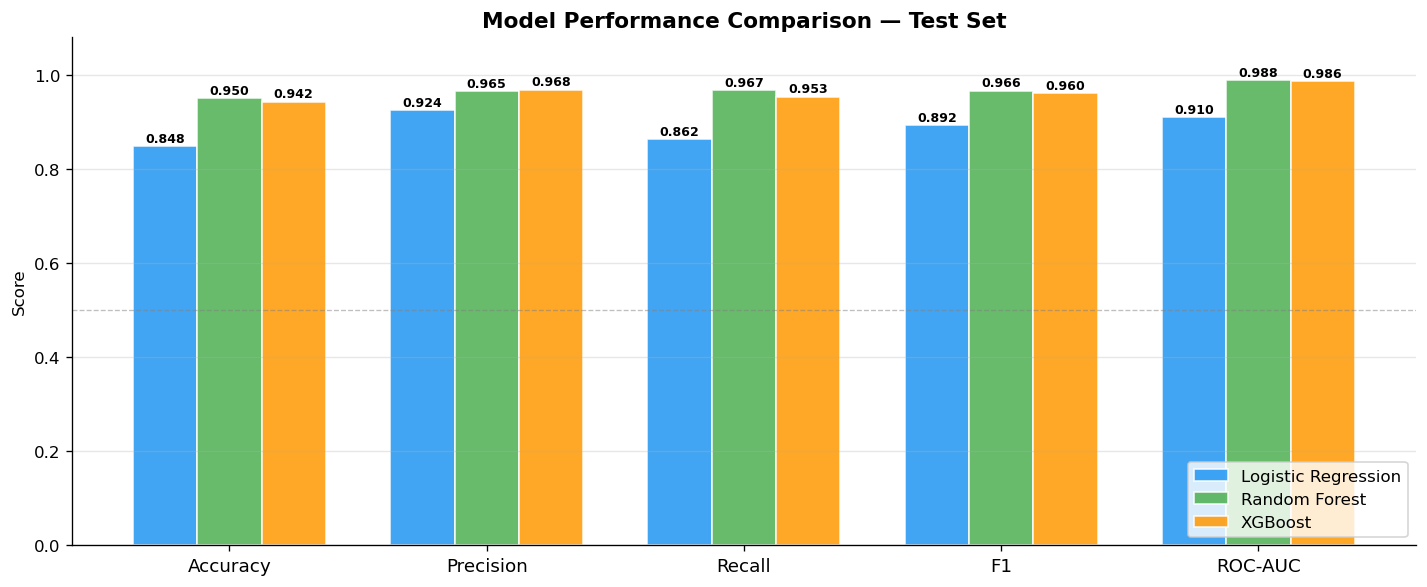

In [34]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
metrics_to_plot = ['Accuracy','Precision','Recall','F1','ROC-AUC']
plot_data = results[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (model, row) in enumerate(plot_data.iterrows()):
    bars = ax.bar(x + i*width, row.values, width, label=model,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

## 6️⃣ Confusion Matrices

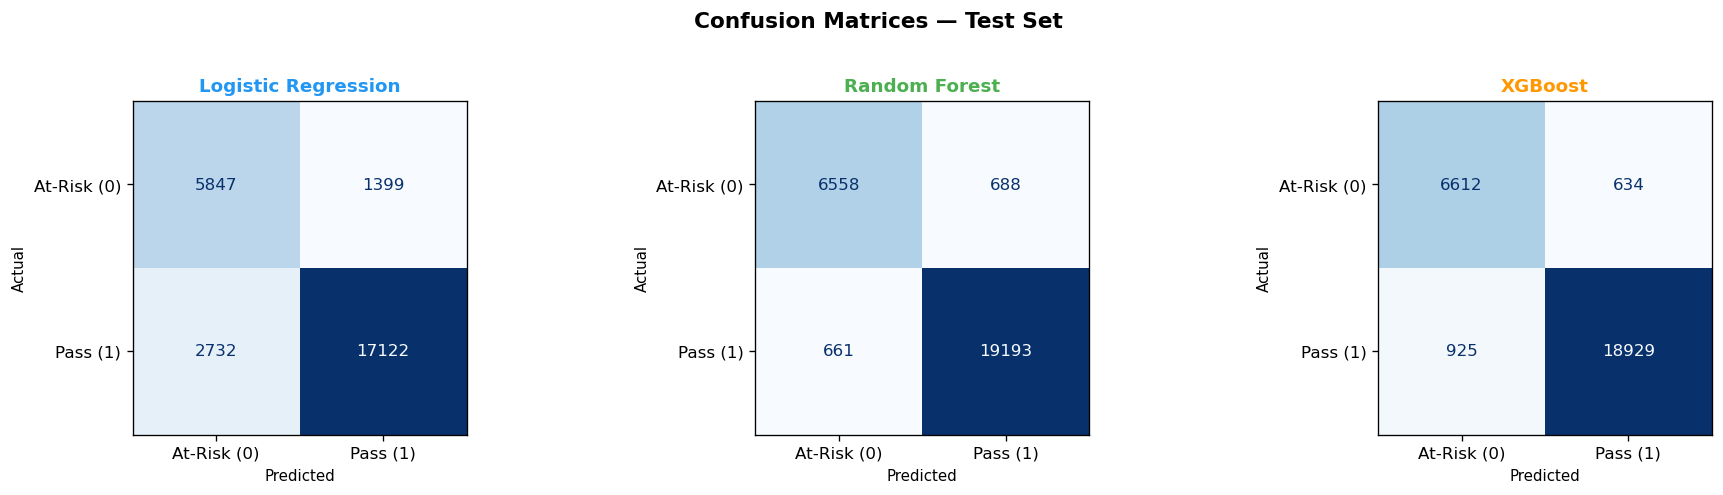

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_info = [
    ('Logistic Regression', lr_test_pred,  '#2196F3'),
    ('Random Forest',       rf_test_pred,  '#4CAF50'),
    ('XGBoost',             xgb_test_pred, '#FF9800'),
]

for ax, (name, preds, color) in zip(axes, model_info):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['At-Risk (0)', 'Pass (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

fig.suptitle('Confusion Matrices — Test Set', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

## 7️⃣ ROC-AUC Curves

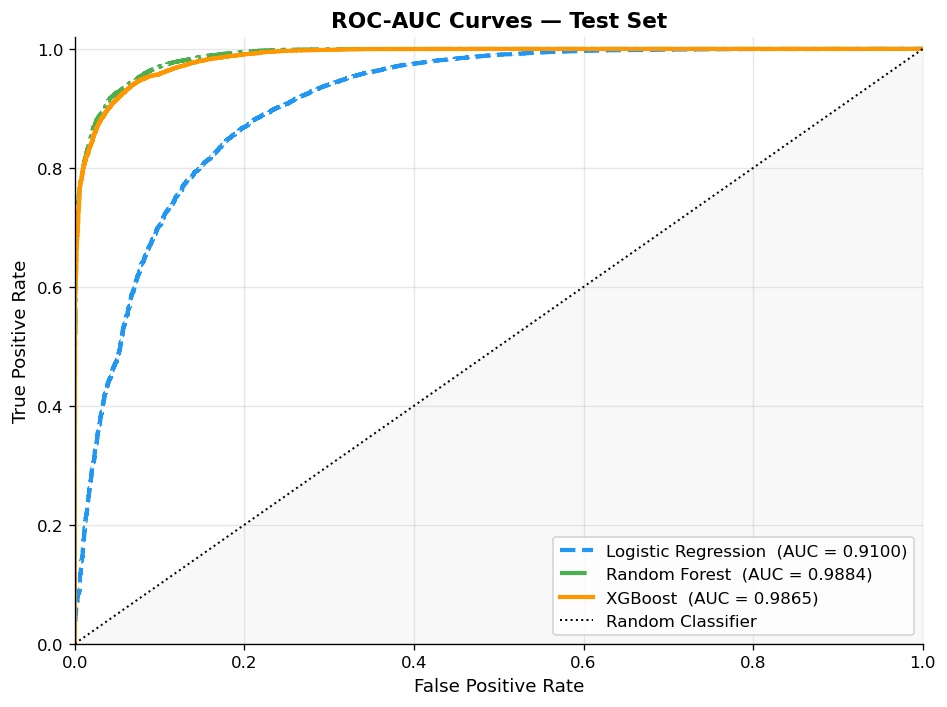

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

prob_map = [
    ('Logistic Regression', lr_test_prob,  '#2196F3', '--'),
    ('Random Forest',       rf_test_prob,  '#4CAF50', '-.'),
    ('XGBoost',             xgb_test_prob, '#FF9800', '-'),
]

for name, probs, color, ls in prob_map:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2.5, linestyle=ls,
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0,1],[0,1], 'k:', lw=1.2, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC-AUC Curves — Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

## 8️⃣ Feature Importance Analysis

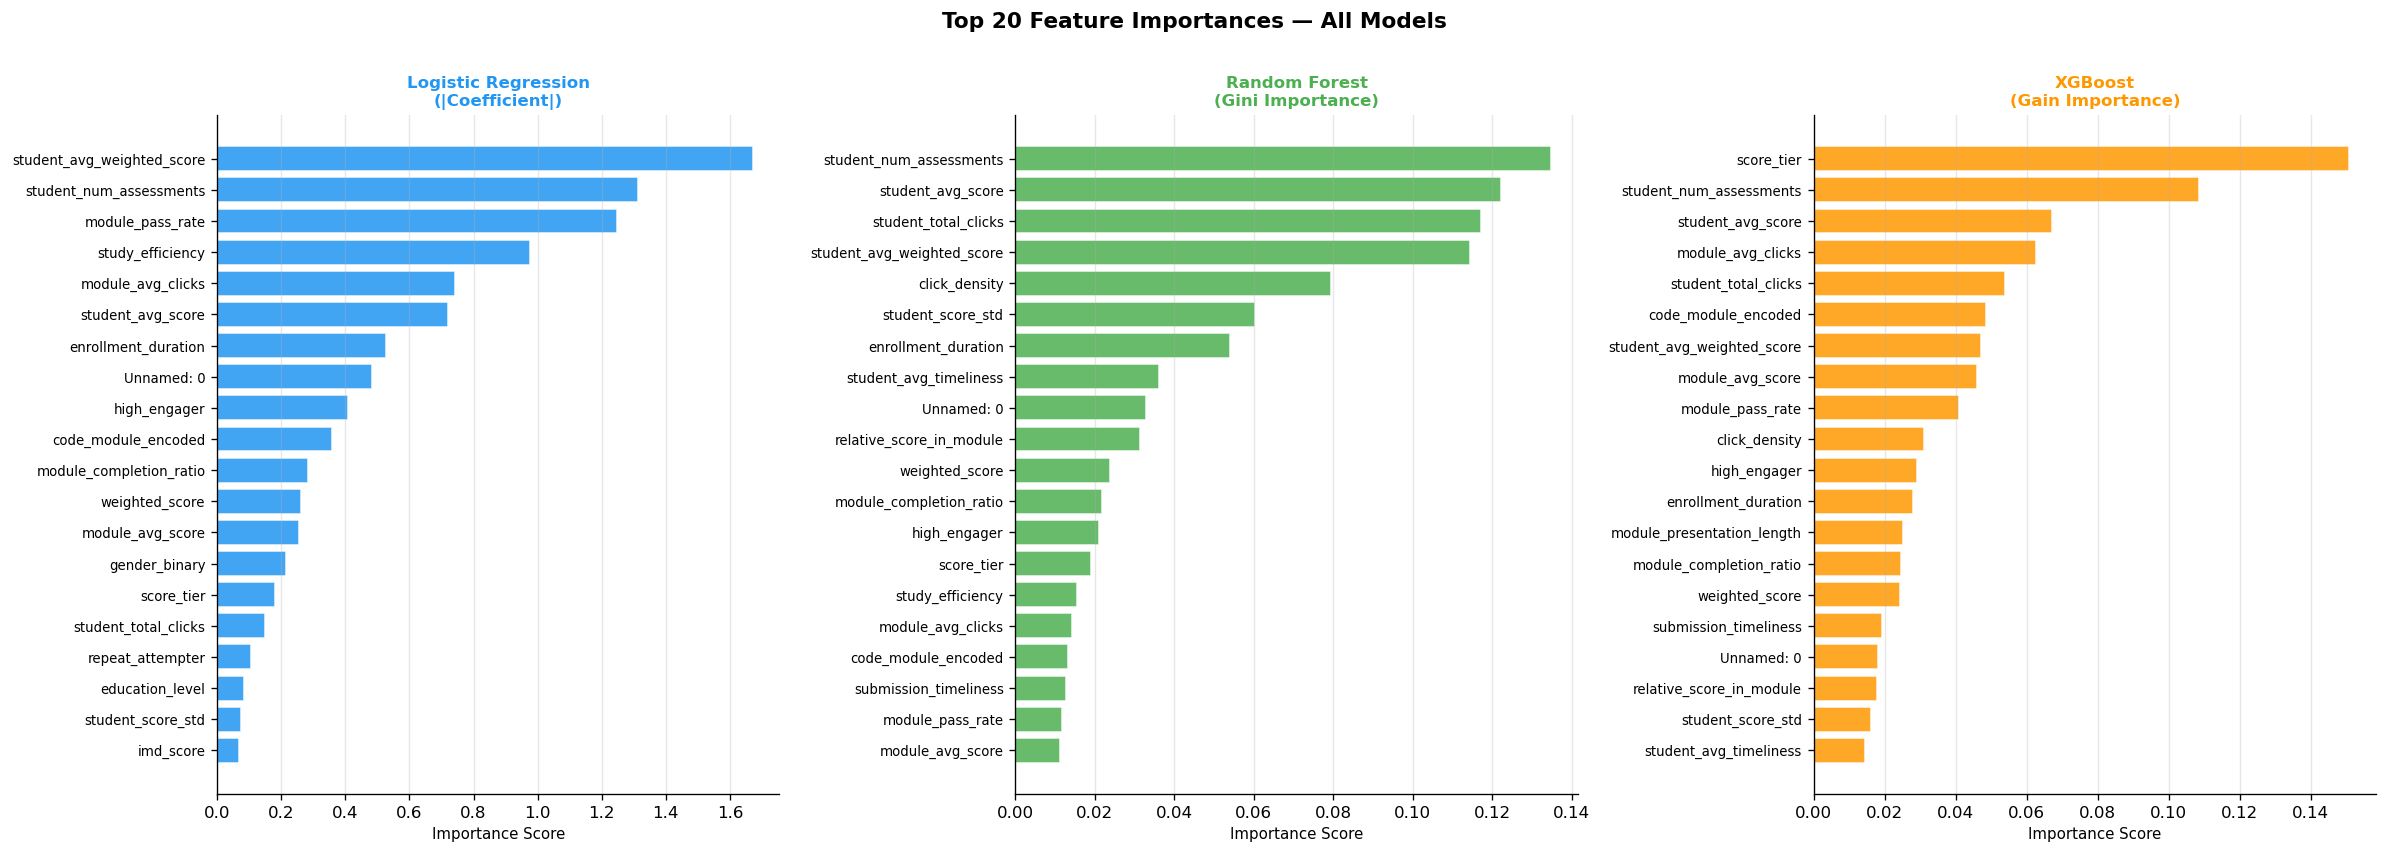

In [37]:
# ── Random Forest Importance ───────────────────────────────────────────────────
rf_imp  = pd.Series(rf_model.feature_importances_, index=FEATURE_NAMES)

# ── XGBoost Importance (gain) ──────────────────────────────────────────────────
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_NAMES)

# ── Logistic Regression Coefficients (magnitude) ──────────────────────────────
lr_coef = pd.Series(
    np.abs(lr_pipeline.named_steps['clf'].coef_[0]),
    index=FEATURE_NAMES
)

TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800']
imp_data = [
    ('Logistic Regression\n(|Coefficient|)',   lr_coef,  colors[0]),
    ('Random Forest\n(Gini Importance)',       rf_imp,   colors[1]),
    ('XGBoost\n(Gain Importance)',             xgb_imp,  colors[2]),
]

for ax, (title, imp, color) in zip(axes, imp_data):
    top = imp.nlargest(TOP_N).sort_values(ascending=True)
    bars = ax.barh(range(len(top)), top.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Importance Score', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    sns.despine(ax=ax)

fig.suptitle(f'Top {TOP_N} Feature Importances — All Models', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [38]:
# ── Consensus Rank: average normalised importance across all 3 models ──────────
def normalise(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

consensus = (
    normalise(lr_coef) +
    normalise(rf_imp)  +
    normalise(xgb_imp)
) / 3
consensus = consensus.sort_values(ascending=False)

print("🏆 Consensus Top 15 Features (Normalised Avg across all 3 models):")
print(consensus.head(15).round(4).to_frame(name='Consensus Score').to_string())

🏆 Consensus Top 15 Features (Normalised Avg across all 3 models):
                            Consensus Score
student_num_assessments              0.8350
student_avg_weighted_score           0.7207
student_avg_score                    0.5942
student_total_clicks                 0.4388
score_tier                           0.4164
module_pass_rate                     0.3685
module_avg_clicks                    0.3219
enrollment_duration                  0.3007
click_density                        0.2752
study_efficiency                     0.2447
Unnamed: 0                           0.2179
code_module_encoded                  0.2118
student_score_std                    0.1999
high_engager                         0.1983
module_avg_score                     0.1801


## 9️⃣ Cross-Validation Score Comparison

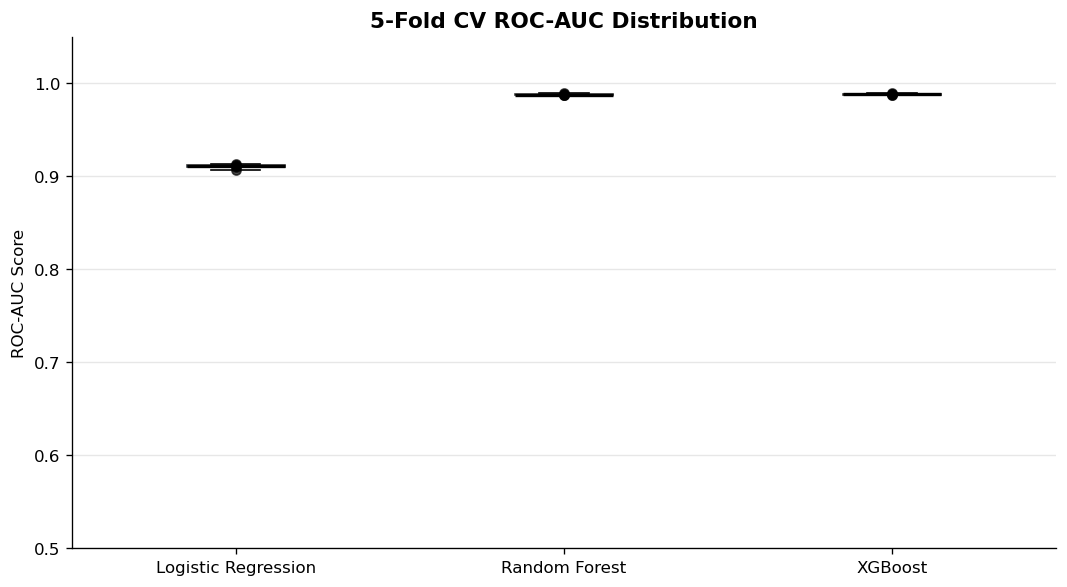


📋 CV Summary:
   Logistic Regression      : 0.9112 ± 0.0023
   Random Forest            : 0.9882 ± 0.0007
   XGBoost                  : 0.9888 ± 0.0009


In [39]:
cv_data = {
    'Logistic Regression': lr_cv_scores,
    'Random Forest'      : rf_cv_scores,
    'XGBoost'            : xgb_cv_scores
}

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    [cv_data[m] for m in cv_data],
    labels=list(cv_data.keys()),
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(bp['boxes'], ['#2196F3','#4CAF50','#FF9800']):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Overlay scatter
for i, (m, scores) in enumerate(cv_data.items(), start=1):
    ax.scatter([i]*len(scores), scores, color='black', s=30, zorder=5, alpha=0.7)

ax.set_title('5-Fold CV ROC-AUC Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC Score')
ax.set_ylim(0.5, 1.05)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print("\n📋 CV Summary:")
for m, scores in cv_data.items():
    print(f"   {m:<25}: {scores.mean():.4f} ± {scores.std():.4f}")

## 🔟 Save Trained Models

In [40]:
joblib.dump(lr_pipeline, 'model_logistic_regression.pkl')
joblib.dump(rf_model,    'model_random_forest.pkl')
joblib.dump(xgb_model,   'model_xgboost.pkl')

results.to_csv('model_comparison_results.csv')

print("💾 Saved:")
print("   model_logistic_regression.pkl")
print("   model_random_forest.pkl")
print("   model_xgboost.pkl")
print("   model_comparison_results.csv")

💾 Saved:
   model_logistic_regression.pkl
   model_random_forest.pkl
   model_xgboost.pkl
   model_comparison_results.csv


---
## 📋 Results Summary

| Model | Role | Strengths | Best For |
|---|---|---|---|
| **Logistic Regression** | Baseline | Interpretable, fast, coefficients explain direction | Reporting & audit |
| **Random Forest** | Ensemble | Non-linear, robust, stable feature importance | Production baseline |
| **XGBoost** | Boosting | Highest accuracy, handles interactions, regularised | Final deployment |

---
## ⏭️ Next Steps

### Step A — Hyperparameter Tuning
- Use `GridSearchCV` or `Optuna` to tune best model (likely XGBoost)
- Key params: `max_depth`, `learning_rate`, `n_estimators`, `subsample`

### Step B — Feature Drift / Temporal Stability Analysis
- Split data by `code_presentation` (semester) → train on early, test on later
- Compute PSI (Population Stability Index) per feature across presentations
- Identify unstable features (PSI > 0.2 = high drift)

### Step C — Model Degradation Analysis
- Re-evaluate model on each presentation separately
- Plot ROC-AUC / F1 across time to detect performance degradation
- Quantify how much accuracy drops when training distribution shifts

### Step D — SHAP Explainability
- Use `shap.TreeExplainer` on Random Forest / XGBoost
- Generate SHAP summary plots and force plots for individual students
- Use SHAP values to explain early intervention recommendations

### Step E — Early Intervention System
- Apply trained XGBoost at mid-module checkpoint (e.g., day 60 / 50% completion)
- Flag students with predicted probability of passing < 0.4 as at-risk
- Generate per-student risk scores and top contributing factors

## 1️⃣1️⃣ Recommendation Engine for Educators

In [41]:
recommendation_map = {
    'relative_score_in_module': 'Provide remedial academic support and additional practice assessments.',
    'sum_click': 'Increase LMS engagement through weekly activities and monitored participation.',
    'score': 'Arrange tutoring sessions and targeted academic support.',
    'module_pass_rate': 'Provide supplementary study materials and mentoring.',
    'imd_score': 'Offer financial aid guidance and mentoring support.',
    'studied_credits': 'Review academic workload and provide study planning assistance.',
    'num_of_prev_attempts': 'Schedule academic counselling and progress monitoring.'
}

def risk_level(prob):
    if prob >= 0.80:
        return 'High Risk'
    elif prob >= 0.50:
        return 'Medium Risk'
    return 'Low Risk'


In [42]:
def get_recommendations(student_row, feature_ranking=None):
    recommendations = []

    if feature_ranking is not None:
        for feat in feature_ranking[:3]:
            if feat in recommendation_map:
                recommendations.append(recommendation_map[feat])
    else:
        for feat, msg in recommendation_map.items():
            if feat in student_row.index:
                recommendations.append(msg)

    return list(dict.fromkeys(recommendations))


In [43]:
# Demo on one student from test set

sample_student = X_test.iloc[[0]]

risk_prob = xgb_model.predict_proba(sample_student)[0][1]

print('='*60)
print('STUDENT DROPOUT RISK ANALYSIS')
print('='*60)
print(f'Risk Probability : {risk_prob:.2%}')
print(f'Risk Level       : {risk_level(risk_prob)}')

top_features = consensus.head(3).index.tolist()

print('\nTop Risk Factors:')
for i,f in enumerate(top_features,1):
    print(f'{i}. {f}')

print('\nRecommended Educator Actions:')
for rec in get_recommendations(sample_student.iloc[0], top_features):
    print('•', rec)


STUDENT DROPOUT RISK ANALYSIS
Risk Probability : 68.49%
Risk Level       : Medium Risk

Top Risk Factors:
1. student_num_assessments
2. student_avg_weighted_score
3. student_avg_score

Recommended Educator Actions:


## 1️⃣2️⃣ SHAP Explainability & Personalized Recommendations

SHAP PERSONALIZED DROPOUT ANALYSIS
Risk Probability : 68.49%
Risk Level       : Medium Risk

Top Personalized Risk Factors:
1. student_num_assessments
2. click_density
3. module_avg_clicks

Recommended Educator Actions:

Generating SHAP Waterfall Plot...


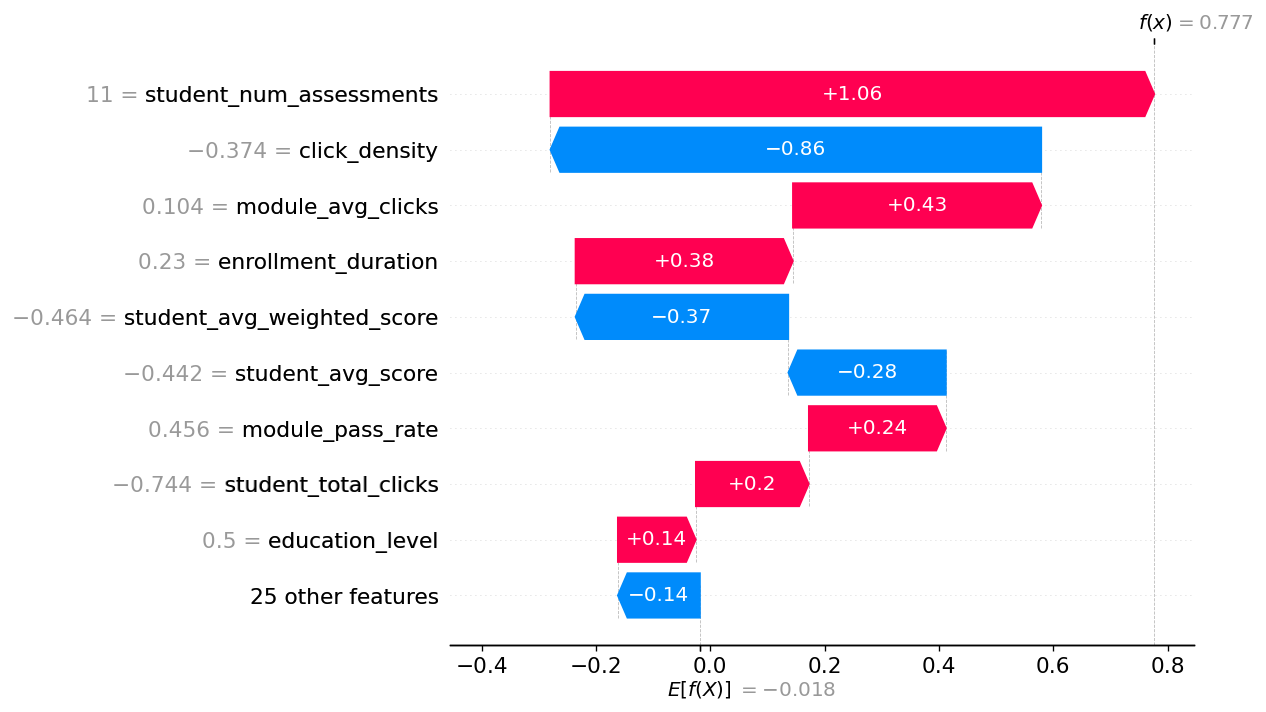

In [44]:

# Install if needed:
# pip install shap

import shap
import numpy as np
import pandas as pd

print("="*60)
print("SHAP PERSONALIZED DROPOUT ANALYSIS")
print("="*60)

# Sample student
sample_student = X_test.iloc[[0]]

# SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)

try:
    shap_values = explainer.shap_values(sample_student)

    if isinstance(shap_values, list):
        shap_array = np.array(shap_values[1][0])
    else:
        shap_array = np.array(shap_values[0])

    impact_df = pd.DataFrame({
        "feature": X_test.columns,
        "impact": np.abs(shap_array)
    }).sort_values("impact", ascending=False)

    top_features = impact_df.head(3)["feature"].tolist()

    risk_prob = xgb_model.predict_proba(sample_student)[0][1]

    print(f"Risk Probability : {risk_prob:.2%}")
    print(f"Risk Level       : {risk_level(risk_prob)}")

    print("\nTop Personalized Risk Factors:")
    for i, feat in enumerate(top_features, 1):
        print(f"{i}. {feat}")

    print("\nRecommended Educator Actions:")
    for rec in get_recommendations(sample_student.iloc[0], top_features):
        print("•", rec)

    print("\nGenerating SHAP Waterfall Plot...")

    try:
        explanation = shap.Explanation(
            values=shap_array,
            base_values=explainer.expected_value if np.isscalar(explainer.expected_value) else explainer.expected_value[0],
            data=sample_student.iloc[0].values,
            feature_names=X_test.columns
        )
        shap.plots.waterfall(explanation, max_display=10)
    except Exception as e:
        print("Waterfall plot could not be generated:", e)

except Exception as e:
    print("SHAP analysis error:", e)
    print("Verify shap is installed and XGBoost model is available.")
